# Основы глубинного обучения, майнор ИАД

## Домашнее задание 1: полносвязные сети

**ФИО:** Макаров Илья Даниилович

**Факт о себе:** Это домашнее задание я делал в 2.5 разных странах


*(Китай, Южная Корея, Гонконг - 0.5 отдельной страны)*

## Общая информация

__Дата выдачи:__ 22.09.2025

__Мягкий дедлайн:__ 23:59MSK 12.10.2025

__Жесткий дедлайн:__ 23:59MSK 19.10.2025


## Оценивание и штрафы

Максимально допустимая оценка за работу — 10 баллов. Сдавать задание после указанного срока сдачи нельзя.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).  Если два студента сгенерировали в нейронке одинаковые либо похожие решения, это считается плагиатом и приводит к обнулению обеих работ.

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

Итогова оценка считается как

$$
min(part_1, part_2) \cdot 0.6 + max(part_1, part_2) \cdot 0.2 + part_3 \cdot 0.2
$$

где $part_1$, $part_2$ и $part_3$ - оценки за первую, вторую и третью части работы

> Также, за домашнее задание выставляется 0, если не сделано нулевое задание либо нет подробного описания ваших экспериментов в третьей части.

## Оформление

1. Обязательно фиксируйте зерно генератора случайных чисел в экспериментах. При перезапуске кода значения не должны меняться.
2. Вверху файла подпишите фамилию, имя и какой-то занимательный факт о себе.
3. Обратите внимание, что у графиков должны быть подписаны оси, заголовок графика и при необходимости обязательно наличие легенды.

> За отсутствие названий графиков и подписей к осям могут снижаться баллы. Все картинки должны быть самодостаточны и визуально удобны для восприятия, так чтобы не нужно было смотреть ваш код или знать задание, чтобы понять что на них изображено.

Из каждого проведённого эксперимента делайте выводы и фиксируйте их. Эти выводы не должны быть поверхностными и очевидными. Не будьте мудрым королём.

<br>

<center>
<img src="https://raw.githubusercontent.com/hse-ds/iad-deep-learning/refs/heads/master/2025/homeworks/king.png" width="300">
</center>

**Пример плохого вывода:** Синенькая линия идет вверх, а красная вниз. Черненькая идет вниз, а потом вверх.

<br>

<center>
<img src="https://raw.githubusercontent.com/hse-ds/iad-deep-learning/refs/heads/master/2025/homeworks/bad_lines.png" width="600">
</center>

## О задании

Вам предстоит обучить полносвязную нейронную сеть для предсказания года выпуска песни по ее аудио-признакам. Для этого мы будем использовать [Million Songs Dataset](https://samyzaf.com/ML/song_year/song_year.html).

In [232]:
import torch
from torch import nn
import torch.nn.functional as F

import pandas as pd
import numpy as np
import random
import gc
from tqdm.notebook import tqdm
from IPython.display import clear_output
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

Начнем с того, что скачаем и загрузим данные:

In [233]:
!wget -O yearpredictionmsd.zip https://archive.ics.uci.edu/static/public/203/yearpredictionmsd.zip

--2025-10-14 12:24:20--  https://archive.ics.uci.edu/static/public/203/yearpredictionmsd.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘yearpredictionmsd.zip’

yearpredictionmsd.z     [             <=>    ] 201.24M  42.0MB/s    in 4.9s    

2025-10-14 12:24:26 (41.0 MB/s) - ‘yearpredictionmsd.zip’ saved [211011981]



In [234]:
df = pd.read_csv('yearpredictionmsd.zip', header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
0,2001,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,2001,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,2001,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903


Посмотрим на статистики по данным.

In [235]:
df.describe()

,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
count,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,...,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000
mean,1998.397082,43.387126,1.289554,8.658347,1.164124,-6.553601,-9.521975,-2.391089,-1.793236,3.727876,...,15.755406,-73.461500,41.542422,37.934119,0.315751,17.669213,-26.315336,4.458641,20.035136,1.329105
std,10.931046,6.067558,51.580351,35.268585,16.322790,22.860785,12.857751,14.571873,7.963827,10.582861,...,32.099635,175.618889,122.228799,95.050631,16.161764,114.427905,173.977336,13.346557,185.558247,22.088576
min,1922.000000,1.749000,-337.092500,-301.005060,-154.183580,-181.953370,-81.794290,-188.214000,-72.503850,-126.479040,...,-437.722030,-4402.376440,-1810.689190,-3098.350310,-341.789120,-3168.924570,-4319.992320,-236.039260,-7458.378150,-381.424430
25%,1994.000000,39.954690,-26.059520,-11.462710,-8.487500,-20.666450,-18.440990,-10.780600,-6.468420,-2.293660,...,-1.812650,-139.555160,-20.986900,-4.669540,-6.781590,-31.580610,-101.530300,-2.566090,-59.509270,-8.820210
50%,2002.000000,44.258500,8.417850,10.476320,-0.652840,-6.007770,-11.188390,-2.046670,-1.736450,3.822310,...,9.171850,-53.090060,28.791060,33.623630,0.820840,15.598470,-21.204120,3.117640,7.759730,0.053050
75%,2006.000000,47.833890,36.124010,29.764820,8.787540,7.741870,-2.388960,6.508580,2.913450,9.961820,...,26.274480,13.478730,89.661770,77.785800,8.470990,67.794960,52.389330,9.967740,86.351610,9.679520
max,2011.000000,61.970140,384.065730,322.851430,335.771820,262.068870,166.236890,172.402680,126.741270,146.297950,...,840.973380,4469.454870,3210.701700,1734.079690,260.544900,3662.065650,2833.608950,463.419500,7393.398440,677.899630


Целевая переменная, год выпуска песни, записана в первом столбце. Посмотрим на ее распределение.

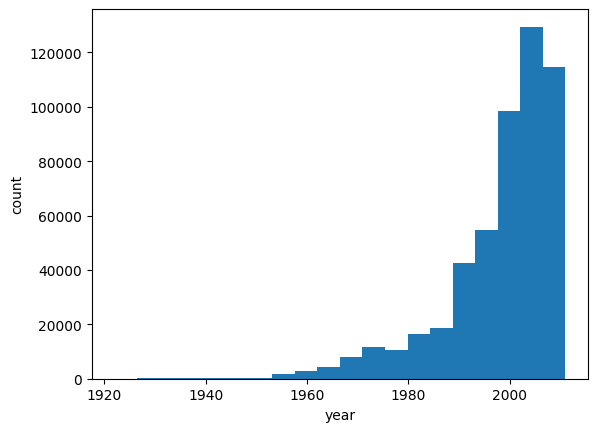

Range: 1922 - 2011
Unique values: 89


In [236]:
plt.hist(df.iloc[:, 0], bins=20)
plt.xlabel('year')
plt.ylabel('count')
plt.show()
print(f'Range: {df.iloc[:, 0].min()} - {df.iloc[:, 0].max()}')
print(f'Unique values: {np.unique(df.iloc[:, 0]).size}')

Разобьем данные на обучение и тест (не меняйте здесь ничего, чтобы сплит был одинаковым у всех).

## Полезные советы:

- Если вы сразу реализуете обучение на GPU, то у вас будет больше времени на эксперименты, так как любые вычисления будут работать быстрее. Google Colab предоставляет несколько GPU-часов (обычно около 8-10) в сутки бесплатно.

- Если вы чего-то не знаете, не стесняйтесь гуглить. В интернете очень много полезной информации, туториалов и советов по глубинному обучению и `pytorch`. Но не забывайте, что за списанный код без ссылки на источник последует наказание.

- Чтобы отладить код, можете обучаться на небольшой части данных или даже на одном батче. Если лосс на обучающей выборке не падает, то что-то точно идет не так.

- Пользуйтесь утилитами, которые вам предоставляет `pytorch` (например, `Dataset` и `Dataloader`). Их специально разработали для упрощения разработки пайплайна обучения.

- Скорее всего, вы захотите отслеживать прогресс обучения. Для создания прогресс-баров есть удобная библиотека `tqdm`.

- Быть может, вы захотите, чтобы графики рисовались прямо во время обучения. Можете воспользоваться функцией [clear_output](http://ipython.org/ipython-doc/dev/api/generated/IPython.display.html#IPython.display.clear_output), чтобы удалять старый график и рисовать новый на его месте.

- При желании вы можете логгировать метрики обучения и свои эксперименты в WandB либо любой другой сервис. Не забудьте приложить к тетрадке ссылку на результаты экспериментов либо скришноты графиков с пояснениями, что проверяющий должен на них увидеть.

- Финальное значение тестовой метрики для удобства проверки выведите в тетрадке.

In [237]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

train_size = int(0.75 * X.shape[0])

X_train = X[:train_size, :]
y_train = y[:train_size]
X_test = X[train_size:, :]
y_test = y[train_size:]

X_train.shape, X_test.shape, y_test.shape

((386508, 90), (128837, 90), (128837,))

## Задание 0 (0 баллов, но при невыполнении максимальная оценка за всю работу &mdash; 0 баллов)

Мы будем использовать RMSE как метрику качества. Прежде чем обучать нейронные сети, нам нужно проверить несколько простых бейзлайнов, чтобы было с чем сравнить более сложные алгоритмы. Для этого обучите `Ridge` регрессию из `sklearn`. Кроме того, посчитайте качество при наилучшем константном прогнозе.

Для выполнения данного задания (и всех последующих) предобработайте данные.

1. Зафиксируйте random_seed везде где только возможно. Вам предоставлена функция для этого, однако вы можете дополнить ее своими дополнениями.
2. Обучите `StandertScaler` и предобработайте ваши данные. В следующих заданиях можете использовать другой `scaler` или вообще отказаться от него.


In [238]:
def set_global_seed(seed: int) -> None:
    """Set global seed for reproducibility.
    :param int seed: Seed to be set
    """
    torch.backends.cudnn.deterministic = True
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

    # также можно зафиксировать seed для Dataloader
    g = torch.Generator()
    g.manual_seed(seed)
    return g

# Сид для каждого worker в Dataloader
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = set_global_seed(42)

In [239]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
scaler = StandardScaler()
train_X_s = scaler.fit_transform(X_train)
test_X_s = scaler.transform(X_test)
g = set_global_seed(42)
model = Ridge()
model.fit(train_X_s, y_train)
y_pred = model.predict(test_X_s)
rmse_for_model = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'RMSE for Ridge regression: {float(rmse_for_model)}')

RMSE for Ridge regression: 9.47363033268409


Лучшая константа для RMSE это среднее. Используйте среднее, расчитанное на трэйне в качестве прогноза для теста и посчитайте для такой наивной модели RMSE.

In [240]:
g = set_global_seed(42)
train_means = np.mean(y_train)
y_pred_n = np.ones(len(y_test)) * train_means
rmse_for_model_n = np.sqrt(mean_squared_error(y_test, y_pred_n))
best_rmse_metric = min(rmse_for_model, rmse_for_model_n)
print(f'RMSE for naive model: {rmse_for_model_n}')
if rmse_for_model < rmse_for_model_n:
  print(f'RMSE for naive model actuale is worse by {(rmse_for_model_n - rmse_for_model) / rmse_for_model_n * 100}%')

RMSE for naive model: 10.845542969687791
RMSE for naive model actuale is worse by 12.649552363012715%


Теперь приступим к экспериментам с нейросетями. Для начала отделим от данных валидацию. Тестовую выборку мы будем использовать только для того, чтобы измерить итоговую метрику качества модели.

In [241]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=0xE2E4)
X_train.shape, X_val.shape, y_train.shape

((289881, 90), (96627, 90), (289881,))

## Часть I. Обучаем линейную регрессию (максимум 10 баллов)

**Задание 1 (10 баллов):** Обучите в `pytorch` линейную регрессию.

- Создайте модель линейной регрессии, которая будет состоять только из одного `Linear()` слоя.
   
- Напишите цикл обучения вашей линейной регрессии. В нем реализуйте подсчет функции потерь, сделайте шаг градиентного спуска. Запрещено использовать готовые оптимизаторы и loss-функции из библиотеки `pytorch`. Для подсчета градиента воспользуйтесь методом backward.
   
- Запустите обучение на 10 эпохах, после каждой проверяйте значение целевой метрики на тестовой выборке.
   
- Выведите на экран графики метрики и значения функции потерь на тестовой и обучающей выборке.

В данном задании нет цели побить какой-то порог по метрике. Ваша задача &mdash; убедиться в том, что ваш рукописный цикл обучения работает. Для ускорения вычислений и обучения модели можете брать только срез данных, а не весь датасет.

Обучимся только на части данных, так как в ином случае может быть исчерпана ОЗУ. Выберем небольшое значение - допустим, 15% данных.

In [242]:
X_train_part = X_train[:int(len(X_train) * 0.15)]
y_train_part = y_train[:int(len(y_train) * 0.15)]
X_val_part = X_val[:int(len(X_val) * 0.15 * 4/3)]
y_val_part = y_val[:int(len(y_val) * 0.15 * 4/3)]

Обучим StandardScaler, чтобы нормализовать данные. Обучение также сделаем на 15% данных, так как и учить будем на них. В данном случае, непринципиально, а ОЗУ будет сэкономлена.

In [243]:
scaler_X = StandardScaler()
g = set_global_seed(42)
X_train_s = scaler_X.fit_transform(X_train_part)
X_val_s = scaler_X.transform(X_val_part)
X_test_s = scaler_X.transform(X)

In [244]:
X_train_t = torch.tensor(X_train_s, dtype=torch.float32)
y_train_t = torch.tensor(y_train_part, dtype=torch.float32)
X_val_t = torch.tensor(X_val_s, dtype=torch.float32)
y_val_t = torch.tensor(y_val_part, dtype=torch.float32)

Обучим модель с одним линейным слоем, имитирующую линейную регрессию

In [245]:
model = nn.Linear(90, 1).to(device)

Стандартная реализация в данном случае лосс-функции MSE. Из интересного, unsqueeze() нужно для broadcasting, так как y_pred подается в тензорной форме, а y - одномерен

In [246]:
def mse(y_pred, y):
  return torch.mean((y_pred - y.unsqueeze(1)) ** 2)

За основу был взят семинарский код, что более чем вероятно будет повторяться в других решениях. Стандартное обучение линейной регрессии через градиентный спуск с использованием библиотеки pytorch и линейного слоя. Для каждой эпохи обрабатываем входные данные, пропуская их через линейный слой. Считаем лосс по формуле. С помощью backword считаем градиенты. Далее делаем градиентный шаг с learning rate, не забывая обнулить градиенты в конце (чтобы не плюсовались). Проводим процедуру как для тестовой, так и для валидационной выборки.

In [247]:
epo = 10
val_losses = []
train_losses = []
lr = 0.01
g = set_global_seed(42)
for num in range(epo):
  X_train_t = X_train_t.to(device)
  y_train_t = y_train_t.to(device)
  y_pred = model(X_train_t)
  loss = mse(y_pred, y_train_t)
  loss.backward()
  with torch.no_grad():
      model.weight -= lr * model.weight.grad
      model.bias -= lr * model.bias.grad
      model.weight.grad.zero_()
      model.bias.grad.zero_()
  train_losses.append(loss.item())
  with torch.no_grad():
        X_val_t = X_val_t.to(device)
        y_val_t = y_val_t.to(device)
        y_pred_val = model(X_val_t)
        loss_val = mse(y_pred_val, y_val_t)
        val_losses.append(loss_val.item())

In [248]:
train_losses_enum = enumerate(train_losses)
print('Train loss for regression with one linear layer')
for epoch, loss in train_losses_enum:
  print(f'Epoch: {epoch + 1}. Loss: {loss}')

Train loss for regression with one linear layer
Epoch: 1. Loss: 3993717.0
Epoch: 2. Loss: 3835569.0
Epoch: 3. Loss: 3683683.25
Epoch: 4. Loss: 3537812.75
Epoch: 5. Loss: 3397719.25
Epoch: 6. Loss: 3263172.75
Epoch: 7. Loss: 3133954.5
Epoch: 8. Loss: 3009853.75
Epoch: 9. Loss: 2890667.25
Epoch: 10. Loss: 2776200.5


In [249]:
val_losses_enum = enumerate(val_losses)
print('Validation loss for regression with one linear layer')
for epoch, loss in val_losses_enum:
  print(f'Epoch: {epoch + 1}. Loss: {loss}')

Validation loss for regression with one linear layer
Epoch: 1. Loss: 3835427.0
Epoch: 2. Loss: 3683556.5
Epoch: 3. Loss: 3537698.25
Epoch: 4. Loss: 3397616.0
Epoch: 5. Loss: 3263080.5
Epoch: 6. Loss: 3133872.5
Epoch: 7. Loss: 3009780.75
Epoch: 8. Loss: 2890602.75
Epoch: 9. Loss: 2776143.5
Epoch: 10. Loss: 2666216.5


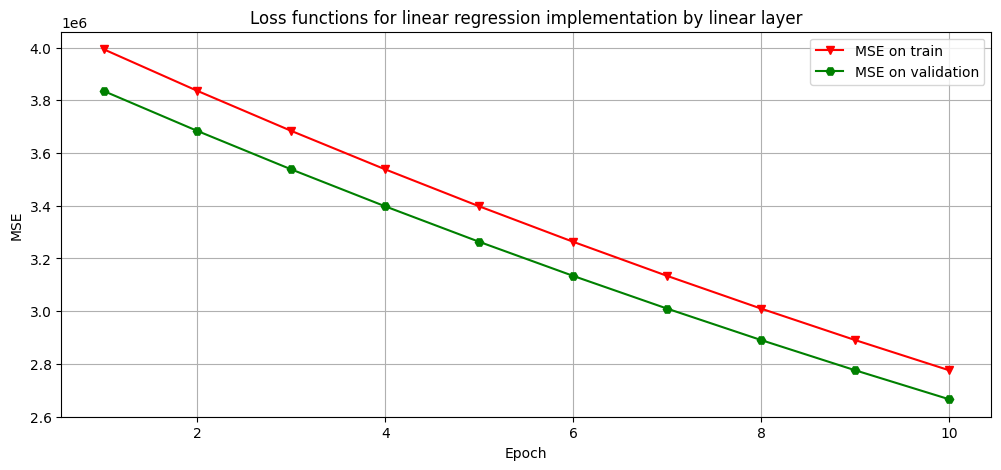

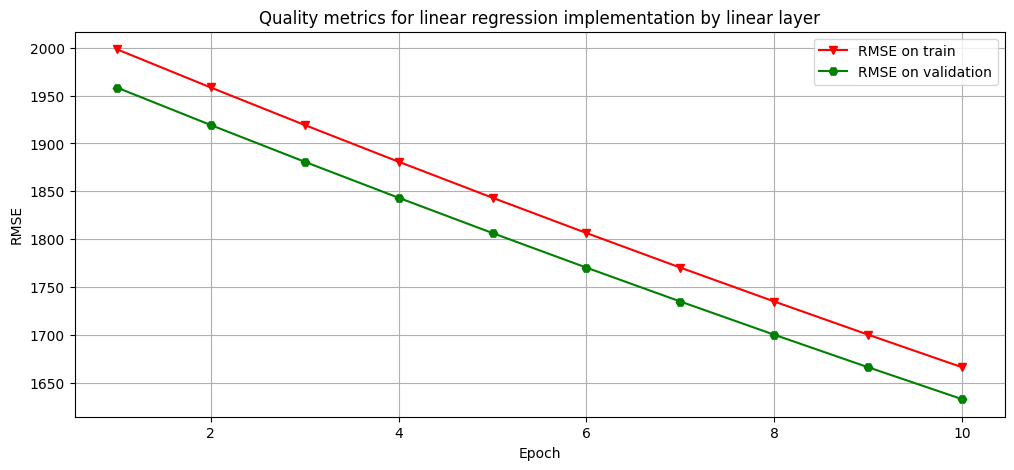

In [250]:
eps = list(range(1, 11))
rmse_tr = np.sqrt(train_losses)
rmse_vl = np.sqrt(val_losses)
plt.figure(figsize=(12, 5))
plt.plot(eps, train_losses, label='MSE on train', color='red', marker='v')
plt.plot(eps, val_losses, label='MSE on validation', color='green', marker='H')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Loss functions for linear regression implementation by linear layer')
plt.legend()
plt.grid(True)
plt.show()
plt.figure(figsize=(12, 5))
plt.plot(eps, rmse_tr, label='RMSE on train', color='red', marker='v')
plt.plot(eps, rmse_vl, label='RMSE on validation', color='green', marker='H')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.title('Quality metrics for linear regression implementation by linear layer')
plt.legend()
plt.grid(True)
plt.show()

Обучить линейную регрессию с помощью линейного слоя нам удалось, однако сложно не отметить очень низкое качество по RMSE, что связано с использованием лишь 15% данных. Тем не менее, что Loss, что RMSE неуклонно снижаются, что говорит о корректности применения метода градиентного спуска через pytorch.

## Часть II. Заводим нейронную сеть (максимум 10 баллов)

Ниже нам предстоит реализовать довольно много различных нейросетей и поставить целую серию экспериментов. Чтобы это всё происходило без боли и страданий, нам нужно держать код в удобном виде.

При решении заданий вы можете придерживаться любой адекватной струкуры кода, но мы советуем воспользоваться сигнатурами функций, которые приведены ниже. При необходимости вы можете добавить в них любые нужные вам аргументы и любой нужный функционал. Более того, хорошей практикой является не делать эти функции слишком громоздкими и выносить разные хитрые штуки в отдельные функции.

Составляем стандартный датасет с наиболее примитивным функционалом - инициализация, возвращение длины и возвращение признаков и целевой переменной по запросу. Код также взят из семинарского ноутбук с незначительными доработками для совместимости.

In [282]:
class SongDataset(torch.utils.data.Dataset):

    def __init__(self, x, y):
        self.x=x
        self.y=y

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return {'sample': torch.tensor(self.x[idx, :], dtype=torch.float), 'target': self.y[idx]}

Реализация функций для обучения моделей и расчета предсказаний. Код для обучения взят из семинарских ноутбуков с доработками для совместимости.Также в реализации присутствует пакет tqdm, позволяющий отслеживать этапы и скорость обучения моделей для удобства запуска.
В training_epoch() происходит обучение модели на каждой эпохе, а внутри эпохи по батчам (я обучал на 64, забегая вперед). Изначально данные делятся на признаки и таргет. Происходит стандартный процесс обучения через градиентный спуск - с поправкой на передаваемый оптимизатор (автоматическая основа для градиентного спуска) и критерион, по которому рассчитывается лосс для батча.
В validation_epoch() шаги делаются по уже обученной модели с градиентами.
В данном фрагменте кода реализован predict() для классификации - по сути,с помощью torch.argmax() выбирается индекс наиболее вероятного класса. Функция train() просто сводит все вместе.

In [252]:
from tqdm.notebook import tqdm

In [283]:
def training_epoch(model, optimizer, criterion, train_loader, tqdm_desc):
    """Одна эпоха обучения
    params:
        model - torch.nn.Module to be fitted
        optimizer - model optimizer
        criterion - loss function from torch.nn
        train_loader - torch.utils.data.Dataloader with train set
    """
    train_loss = 0
    model.train()
    for batch in tqdm(train_loader, desc=tqdm_desc):
        sample = batch['sample'].to(device)
        target = batch['target'].to(device)
        optimizer.zero_grad()
        out = model(sample)
        loss = criterion(out, target)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(sample)
    train_loss /= len(train_loader.dataset)
    return train_loss

@torch.no_grad()
def validation_epoch(model, criterion, val_loader, tqdm_desc):
    """Одна эпоха валидации модели
    params:
        model - torch.nn.Module to be fitted
        criterion - loss function from torch.nn
        val_loader - torch.utils.data.Dataloader with test set
                      (if you wish to validate during training)
    """

    val_loss = 0.0
    model.eval()
    for batch in tqdm(val_loader, desc=tqdm_desc):
        sample = batch['sample'].to(device)
        target = batch['target'].to(device)
        out = model(sample)
        loss = criterion(out, target)
        val_loss += loss.item() * len(sample)
    val_loss /= len(val_loader.dataset)
    return val_loss

@torch.no_grad()
def predict(model, data_loader, tqdm_desc="Predict"):
    """ Предсказания модели
    params:
        model - torch.nn.Module to be evaluated on test set
        criterion - loss function from torch.nn
        data_loader - torch.utils.data.Dataloader with test set
    ----------
    returns:
        predicts - torch.tensor with shape (len(test_loader.dataset), ),
                   which contains predictions for test objects
    """
    model.eval()
    predicts = []
    for batch in tqdm(data_loader, desc=tqdm_desc):
      md = batch['sample'].to(device)
      out = model(md)
      pred_classes = torch.argmax(out, dim=1)
      predicts.append(pred_classes.cpu())
    predicts = torch.cat(predicts, dim=0)
    return predicts


def train(model, optimizer, criterion, train_loader, val_loader, epochs):
    """ Обучение модели
    params:
        model - torch.nn.Module to be fitted
        optimizer - model optimizer
        criterion - loss function from torch.nn
        train_loader - torch.utils.data.Dataloader with train set
        val_loader - torch.utils.data.Dataloader with test set
                      (if you wish to validate during training)
        epochs - number of training epochs
    """

    train_losses = []
    val_losses = []
    for epoch in range(1, epochs + 1):
        train_loss = training_epoch(model, optimizer, criterion, train_loader, tqdm_desc=f'Training {epoch}/{epochs}'
        )
        val_loss = validation_epoch(model, criterion, val_loader, tqdm_desc=f'Validating {epoch}/{epochs}')
        train_losses.append(train_loss)
        val_losses.append(val_loss)
    return train_losses, val_losses

**Задание 2 (2 балла)**

Попробуем обучить нашу первую нейронную сеть. Здесь целевая переменная дискретная &mdash; это год выпуска песни. Поэтому будем учить сеть на классификацию.

- В качестве архитектуры сети возьмите два линейных слоя с активацией ReLU между ними c числом скрытых нейронов, равным 128.
- Используйте SGD с `lr=1e-3`.
- Возьмите размер мини-батча около 32-64, примерно 3-4 эпох обучения должно быть достаточно.
- Также преобразуйте целевую переменную так, чтобы ее значения принимали значения от $0$ до $C-1$, где $C$ &mdash; число классов (лучше передайте преобразованное значение в DataLoader, исходное нам еще пригодится)
- В качестве метрики качества мы используем RMSE. При его подсчёте вам нужно заменить предсказанный нейросеткой класс на конкретный год выпуска песни и использовать его как прогноз.

Вводим два линейных слоя для инициализации модели (ввод 128, вывод 1 - таргет), между ними функция активации ReLU, оборачиваем в Sequential.

In [284]:
class NeuralNet(nn.Module):
    def __init__(self):

      super().__init__()
      self.model = nn.Sequential(
          nn.Linear(90, 128),
          nn.ReLU(),
          nn.Linear(128, 90)
        )

    def forward(self, x):
        return self.model(x)

Приводим тарегет (года выпуска песен) к диапазону [0; 90] путем вычитания минимального года - 1922.

In [285]:
y_train_tr = y_train - 1922
y_val_tr = y_val - 1922
y_test_tr = y_test - 1922

Инициализируем датасеты для обучающей, валидационной и тестовой выборок

In [286]:
train_dataset = SongDataset(X_train, y_train_tr)
val_dataset = SongDataset(X_val, y_val_tr)
test_dataset = SongDataset(X_test, y_test_tr)

Загружаем датасеты в даталоадер. При отладке моделей будет использоваться батч в 54, чтобы сэкономить время обучения, не жертвуя результатом. На финальных тестах батч будет повышен до 64.

In [287]:
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=54, shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=54, shuffle=False
)
val_loader = torch.utils.data.DataLoader(
    val_dataset, batch_size=54, shuffle=False
)

Вводим модель, устанавливаем оптимизатор - стохастический градиентный спуск с шагом 1e-3. Лосс - кроссэнтропия, 4 эпохи (в последующем будут увеличены, на данном этапе хватит и столько)

In [288]:
model = NeuralNet().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
epochs = 4

In [289]:
g = set_global_seed(42)
data = train(model, optimizer, criterion, train_loader, val_loader, epochs)

Training 1/4:   0%|          | 0/5369 [00:00<?, ?it/s]

Validating 1/4:   0%|          | 0/1790 [00:00<?, ?it/s]

Training 2/4:   0%|          | 0/5369 [00:00<?, ?it/s]

Validating 2/4:   0%|          | 0/1790 [00:00<?, ?it/s]

Training 3/4:   0%|          | 0/5369 [00:00<?, ?it/s]

Validating 3/4:   0%|          | 0/1790 [00:00<?, ?it/s]

Training 4/4:   0%|          | 0/5369 [00:00<?, ?it/s]

Validating 4/4:   0%|          | 0/1790 [00:00<?, ?it/s]

In [290]:
train_loss = enumerate(data[0])
print('Train loss for classification with two linear layers')
for epoch, loss in train_loss:
  print(f'Epoch: {epoch + 1}. Loss: {loss}')

Train loss for classification with two linear layers
Epoch: 1. Loss: 4.66427838098015
Epoch: 2. Loss: 4.264147734145339
Epoch: 3. Loss: 4.136363470564345
Epoch: 4. Loss: 4.030768480765468


In [291]:
val_loss = enumerate(data[1])
print('Validation loss for classification with two linear layers')
for epoch, loss in val_loss:
  print(f'Epoch: {epoch + 1}. Loss: {loss}')

Validation loss for classification with two linear layers
Epoch: 1. Loss: 4.340632189293184
Epoch: 2. Loss: 4.200369137091232
Epoch: 3. Loss: 4.08363188943422
Epoch: 4. Loss: 3.9880872914560825


In [292]:
g = set_global_seed(42)
y_pred = predict(model, test_loader)
y_pred = y_pred + 1922
if torch.cuda.is_available():
      y_pred = y_pred.cuda().float()
else:
      y_pred = y_pred.cpu().float()
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)
squared_errors = (y_pred - y_test_tensor) ** 2
mse = torch.mean(squared_errors)
rmse = torch.sqrt(mse)
print(f"RMSE for classfication with two linear layers: {rmse.item():.5f}")

Predict:   0%|          | 0/2386 [00:00<?, ?it/s]

RMSE for classfication with two linear layers: 13.81076


**Задание 3 (1 балл).** Прокомментируйте ваши наблюдения. Удалось ли побить бейзлайн? Как вы думаете, хорошая ли идея учить классификатор для этой задачи? Почему?

**Ответ:** Побить бейзлайн Ridge Regression не удалось (13.8 < 9.47). Тем не менее, лосс убывает. Простая двухслойная нейросеть явно справляется с задачей хуже. Стоит учитывать также структуру метрики RMSE, которая предназначена для оценивания качества решения задач регрессии, а не классификации на основе логитов, что также влечет ухудшение качества метрики относительно регрессии. Порядковый характер зависимой переменной с большим числом градаций (90) говорит о псевдоинтервальности шкалы, то есть зависимую переменную стоит воспринимать как порядковую в связи с ее продолжительностью. Связано это, в том числе, с банальным недостатком признаков, чтобы определить год песни 1997 или 1998, например. В данной задаче классификация неуместна.


**Задание 4 (2 балла).** Теперь попробуем решать задачу как регрессию. Обучите нейронную сеть на MSE.

- Используйте такие же гиперпараметры обучения.
- Когда передаете целевую переменную в DataLoader, сделайте reshape в (-1, 1).
- Если что-то пойдет не так, можете попробовать меньшие значения `lr`.

Приведение таргета в формат двумерного столбца с одной колонкой

In [293]:
y_train_tr = ((y_train - 1922).astype(np.float32)).reshape(-1, 1)
y_val_tr = ((y_val - 1922).astype(np.float32)).reshape(-1, 1)
y_test_tr = ((y_test - 1922).astype(np.float32)).reshape(-1, 1)

In [294]:
class SongDataset(torch.utils.data.Dataset):

    def __init__(self, x, y):
        self.x=x
        self.y=y

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return {'sample': torch.tensor(self.x[idx, :], dtype=torch.float), 'target': torch.tensor(self.y[idx], dtype=torch.float32)}

In [295]:
class NeuralNet(nn.Module):
    def __init__(self):

      super().__init__()
      self.model = nn.Sequential(
          nn.Linear(90, 128),
          nn.ReLU(),
          nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.model(x)

In [296]:
train_dataset = SongDataset(X_train, y_train_tr)
val_dataset = SongDataset(X_val, y_val_tr)
test_dataset = SongDataset(X_test, y_test_tr)
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=54, shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=54, shuffle=False
)
val_loader = torch.utils.data.DataLoader(
    val_dataset, batch_size=54, shuffle=False
)

In [297]:
model = NeuralNet().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=1e-5)
criterion = nn.MSELoss()
epochs = 4

Функция predict() для регрессии

In [298]:
@torch.no_grad()
def predict(model, data_loader, tqdm_desc="Predict"):
    """ Предсказания модели
    params:
        model - torch.nn.Module to be evaluated on test set
        criterion - loss function from torch.nn
        data_loader - torch.utils.data.Dataloader with test set
    ----------
    returns:
        predicts - torch.tensor with shape (len(test_loader.dataset), ),
                   which contains predictions for test objects
    """
    model.eval()
    predicts = []
    for batch in tqdm(data_loader, desc=tqdm_desc):
      sample = batch['sample'].to(device)
      out = model(sample).squeeze(-1)
      predicts.append(out.cpu())
    predicts = torch.cat(predicts, dim=0)
    return predicts

In [299]:
g = set_global_seed(42)
data = train(model, optimizer, criterion, train_loader, val_loader, epochs)

Training 1/4:   0%|          | 0/5369 [00:00<?, ?it/s]

Validating 1/4:   0%|          | 0/1790 [00:00<?, ?it/s]

Training 2/4:   0%|          | 0/5369 [00:00<?, ?it/s]

Validating 2/4:   0%|          | 0/1790 [00:00<?, ?it/s]

Training 3/4:   0%|          | 0/5369 [00:00<?, ?it/s]

Validating 3/4:   0%|          | 0/1790 [00:00<?, ?it/s]

Training 4/4:   0%|          | 0/5369 [00:00<?, ?it/s]

Validating 4/4:   0%|          | 0/1790 [00:00<?, ?it/s]

In [300]:
train_loss = enumerate(data[0])
print('Train loss for regression with two linear layers')
for epoch, loss in train_loss:
  print(f'Epoch: {epoch + 1}. Loss: {loss}')

Train loss for regression with two linear layers
Epoch: 1. Loss: 880723238432.9297
Epoch: 2. Loss: 1037619.036610497
Epoch: 3. Loss: 837031.6970314974
Epoch: 4. Loss: 675281.6899876588


In [301]:
val_loss = enumerate(data[1])
print('Validation loss for regression with two linear layers')
for epoch, loss in val_loss:
  print(f'Epoch: {epoch + 1}. Loss: {loss}')

Validation loss for regression with two linear layers
Epoch: 1. Loss: 1152779.8343979944
Epoch: 2. Loss: 930069.503017402
Epoch: 3. Loss: 750334.7110939489
Epoch: 4. Loss: 605340.6638847061


In [302]:
g = set_global_seed(42)
y_pred = predict(model, test_loader) + 1922
rmse = (torch.mean((y_pred - torch.tensor(y_test))**2))**0.5
print(f'RMSE for egression with two linear layers: {rmse.item():.5f}')

Predict:   0%|          | 0/2386 [00:00<?, ?it/s]

RMSE for egression with two linear layers: 777.95367


**Задание 5 (1 балл).** Получилось ли у вас стабилизировать обучение? Помогли ли меньшие значения `lr`? Стало ли лучше от замены классификации на регрессию? Как вы думаете, почему так происходит? В качестве подсказки можете посмотреть на распределение целевой переменной и магнитуду значений признаков.

**Ответ:** Стабилизация не удалась. Как можно видеть по огромным или пропущенным (ниже) значениям лосса по эпохам и, очевидно, финальной метрики качества происходит "взрыв градиента", что связано с слишком быстрым накоплением градиентов с высокими значениями. По распределению целевой переменной видно, что большинство песен в датасете приходятся на небольшое число лет (медиана - 2002 год, первый квартиль в 1994, при том, что минимальная дата выхода песни - 1922). Скорее всего, подобный инконсистентность целевой переменной и является причиной проблем с градиентами. Логичный шаг с снижением learning rate не принес ощутимого успеха (все также огромные значения лосса), что может быть связано с проблемами в области признаков. Для признаков также характерна высокая скученность вокруг среднего (низкое стандартное отклонение). Отказ от классификации выглядит все также логичным, тем не менее, стоит нормализовать как независимые, так и зависимую переменные для успешного решения задачи регрессии.

**Задание 6 (1 балл).** Начнем с того, что попробуем отнормировать целевую переменную. Для этого воспользуемся min-max нормализацией, чтобы целевая переменная принимала значения от 0 до 1. Реализуйте функции `normalize` и `denormalize`, которые, соответственно, нормируют целевую переменную и применяют обратное преобразование. Минимум и максимум оцените по обучающей выборке (то есть эти константы должны быть фиксированными и не зависеть от передаваемой выборки).

In [303]:
mn_y = y_train.min()
mx_y = y_train.max()

In [304]:
def normalize(sample):
    """
    Min-max normalization to convert sample to [0, 1] range
    """
    return (sample - mn_y) / (mx_y - mn_y)

def denormalize(sample):
    """
    Denormalize sample from [0, 1] to initial range
    """
    return sample * (mx_y - mn_y) + mn_y

**Задание 7 (1 балл)** Теперь повторите эксперимент из **задания 4**, обучаясь на нормированной целевой переменной. Сделаем также еще одно изменение: добавим сигмоидную активацию после последнего линейного слоя сети. Таким образом мы гарантируем, что нейронная сеть предсказывает числа из промежутка $[0, 1]$. Использование активации - довольно распространенный прием, когда мы хотим получить числа из определенного диапазона значений.

In [320]:
class NeuralNet(nn.Module):
    def __init__(self):

      super().__init__()
      self.model = nn.Sequential(
          nn.Linear(90, 128),
          nn.ReLU(),
          nn.Linear(128, 1),
          nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [321]:
y_train_tr = normalize(y_train).astype(np.float32).reshape(-1, 1)
y_val_tr = normalize(y_val).astype(np.float32).reshape(-1, 1)
y_test_tr = normalize(y_test).astype(np.float32).reshape(-1, 1)

In [322]:
train_dataset = SongDataset(X_train, y_train_tr)
val_dataset = SongDataset(X_val, y_val_tr)
test_dataset = SongDataset(X_test, y_test_tr)
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=54, shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=54, shuffle=False
)
val_loader = torch.utils.data.DataLoader(
    val_dataset, batch_size=54, shuffle=False
)

In [323]:
g = set_global_seed(42)
data = train(model, optimizer, criterion, train_loader, val_loader, epochs)

Training 1/10:   0%|          | 0/5369 [00:00<?, ?it/s]

Validating 1/10:   0%|          | 0/1790 [00:00<?, ?it/s]

Training 2/10:   0%|          | 0/5369 [00:00<?, ?it/s]

Validating 2/10:   0%|          | 0/1790 [00:00<?, ?it/s]

Training 3/10:   0%|          | 0/5369 [00:00<?, ?it/s]

...

Validating 8/10:   0%|          | 0/1790 [00:00<?, ?it/s]

Training 9/10:   0%|          | 0/5369 [00:00<?, ?it/s]

Validating 9/10:   0%|          | 0/1790 [00:00<?, ?it/s]

Training 10/10:   0%|          | 0/5369 [00:00<?, ?it/s]

Validating 10/10:   0%|          | 0/1790 [00:00<?, ?it/s]

In [324]:
train_loss = enumerate(data[0])
print('Train loss for regression with normalized target')
for epoch, loss in train_loss:
  print(f'Epoch: {epoch + 1}. Loss: {loss}')

Train loss for regression with normalized target
Epoch: 1. Loss: nan
Epoch: 2. Loss: nan
Epoch: 3. Loss: nan
Epoch: 4. Loss: nan
Epoch: 5. Loss: nan
Epoch: 6. Loss: nan
Epoch: 7. Loss: nan
Epoch: 8. Loss: nan
Epoch: 9. Loss: nan
Epoch: 10. Loss: nan


In [325]:
val_loss = enumerate(data[1])
print('Validation loss for regression with normalized target')
for epoch, loss in val_loss:
  print(f'Epoch: {epoch + 1}. Loss: {loss}')

Validation loss for regression with normalized target
Epoch: 1. Loss: nan
Epoch: 2. Loss: nan
Epoch: 3. Loss: nan
Epoch: 4. Loss: nan
Epoch: 5. Loss: nan
Epoch: 6. Loss: nan
Epoch: 7. Loss: nan
Epoch: 8. Loss: nan
Epoch: 9. Loss: nan
Epoch: 10. Loss: nan


In [326]:
g = set_global_seed(42)
y_pred = predict(model, test_loader)
y_pred = denormalize(y_pred)
rmse = (torch.mean((y_pred - torch.tensor(y_test))**2))**0.5
print(f'RMSE for regression with normalized target {rmse.item():.5f}')

Predict:   0%|          | 0/2386 [00:00<?, ?it/s]

RMSE for regression with normalized target nan


**Задание 8 (2 балла).** На этот раз попробуем отнормировать не только целевую переменную, но и сами данные, которые подаются сети на вход. Для них будем использовать нормализацию через среднее и стандартное отклонение. Преобразуйте данные и повторите прошлый эксперимент. Скорее всего, имеет смысл увеличить число эпох обучения.

In [327]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)

StandardScaler()

In [328]:
class SongDataset(torch.utils.data.Dataset):

    def __init__(self, x, y):
        self.x=x
        self.y=y

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return {'sample': torch.tensor(self.x[idx, :], dtype=torch.float), 'target': torch.tensor(self.y[idx], dtype=torch.float32)}

In [329]:
class NeuralNet(nn.Module):
    def __init__(self):

      super().__init__()
      self.model = nn.Sequential(
          nn.Linear(90, 128),
          nn.ReLU(),
          nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.model(x)

In [330]:
def normalize(sample):
    """
    Min-max normalization to convert sample to [0, 1] range
    """
    return (sample - mn_y) / (mx_y - mn_y)

def denormalize(sample):
    """
    Denormalize sample from [0, 1] to initial range
    """
    return sample * (mx_y - mn_y) + mn_y

In [331]:
y_train_tr = normalize(y_train).astype(np.float32).reshape(-1, 1)
y_val_tr = normalize(y_val).astype(np.float32).reshape(-1, 1)
y_test_tr = normalize(y_test).astype(np.float32).reshape(-1, 1)

In [332]:
train_dataset = SongDataset(scaler.transform(X_train), y_train_tr)
val_dataset = SongDataset(scaler.transform(X_val), y_val_tr)
test_dataset = SongDataset(scaler.transform(X_test), y_test_tr)
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=54, shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=54, shuffle=False
)
val_loader = torch.utils.data.DataLoader(
    val_dataset, batch_size=54, shuffle=False
)

In [333]:
model = NeuralNet().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()
epochs = 10

In [334]:
g = set_global_seed(42)
data = train(model, optimizer, criterion, train_loader, val_loader, epochs)

Training 1/10:   0%|          | 0/5369 [00:00<?, ?it/s]

Validating 1/10:   0%|          | 0/1790 [00:00<?, ?it/s]

Training 2/10:   0%|          | 0/5369 [00:00<?, ?it/s]

Validating 2/10:   0%|          | 0/1790 [00:00<?, ?it/s]

Training 3/10:   0%|          | 0/5369 [00:00<?, ?it/s]

...

Validating 8/10:   0%|          | 0/1790 [00:00<?, ?it/s]

Training 9/10:   0%|          | 0/5369 [00:00<?, ?it/s]

Validating 9/10:   0%|          | 0/1790 [00:00<?, ?it/s]

Training 10/10:   0%|          | 0/5369 [00:00<?, ?it/s]

Validating 10/10:   0%|          | 0/1790 [00:00<?, ?it/s]

In [335]:
train_loss = enumerate(data[0])
print('Train loss for regression with normalized target and variables')
for epoch, loss in train_loss:
  print(f'Epoch: {epoch + 1}. Loss: {loss}')

Train loss for regression with normalized target and variables
Epoch: 1. Loss: 0.04612689502844906
Epoch: 2. Loss: 0.01978419404374522
Epoch: 3. Loss: 0.015589409743265748
Epoch: 4. Loss: 0.013956346799670935
Epoch: 5. Loss: 0.013174421463005914
Epoch: 6. Loss: 0.012750006853789762
Epoch: 7. Loss: 0.012496996172850256
Epoch: 8. Loss: 0.012333007130683743
Epoch: 9. Loss: 0.012218184161216152
Epoch: 10. Loss: 0.012131248183219746


In [336]:
val_loss = enumerate(data[1])
print('Validation loss for regression with normalized target and variables')
for epoch, loss in val_loss:
  print(f'Epoch: {epoch + 1}. Loss: {loss}')

Validation loss for regression with normalized target and variables
Epoch: 1. Loss: 0.023990573531564995
Epoch: 2. Loss: 0.016992702209793053
Epoch: 3. Loss: 0.014595732870901629
Epoch: 4. Loss: 0.013565472493983273
Epoch: 5. Loss: 0.012980155869807775
Epoch: 6. Loss: 0.012674916921124884
Epoch: 7. Loss: 0.012473335648518512
Epoch: 8. Loss: 0.012348536427403342
Epoch: 9. Loss: 0.012244706055758791
Epoch: 10. Loss: 0.012163426430114121


In [337]:
g = set_global_seed(42)
y_pred = predict(model, test_loader)
y_pred = denormalize(y_pred)
rmse = (torch.mean((y_pred - torch.tensor(y_test))**2))**0.5
print(f'RMSE for regression with normalized target and variables: {rmse.item():.5f}')

Predict:   0%|          | 0/2386 [00:00<?, ?it/s]

RMSE for regression with normalized target and variables: 9.70187


Значение *9.70187*. Что, действительно, близко к Ridge (9.47).

Если вы все сделали правильно, то у вас должно было получиться качество, сравнимое с `Ridge` регрессией.

**Мораль:** как видите, нам пришлось сделать очень много хитрых телодвижений, чтобы нейронная сеть работала хотя бы так же, как и простая линейная модель. Здесь, конечно, показан совсем экстремальный случай, когда без нормализации данных нейронная сеть просто не учится. Как правило, в реальности завести нейронную сеть из коробки не очень сложно, но вот заставить ее работать на полную &mdash; куда более трудоемкая задача. Написание пайплайнов обучения нейросетевых моделей требует большой аккуратности, а дебаг часто превращается в угадайку. К счастью, очень часто на помощь приходит интуиция, и мы надеемся, что вы сможете выработать ее в течение нашего курса. Начнем с двух советов, которые стоит принять на вооружение:

- Обязательно начинаем любые эксперименты с бейзлайнов: без них мы бы не поняли, что нейронная сеть не учится в принципе.
- При постановке эксперментов старайтесь делать минимальное количество изменений за раз (в идеале одно!): только так можно понять, какие конкретно изменения влияют на результат.

## Часть III. Улучшаем нейронную сеть (максимум 10 баллов)

Продолжим экспериментировать с нейронной сетью, чтобы добиться еще лучшего качества.

**Задание 9 (1 балл).** Давайте попробуем другие оптимизаторы. Обучите нейросеть с помощью SGD+momentum и Adam. Опишите свои наблюдения и в дальнейших запусках используйте лучший оптимизатор. Для Adam обычно берут learning rate поменьше, в районе $10^{-3}$.

Добавляем моментум = 0.9 в оптимайзер

In [338]:
model = NeuralNet().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)
criterion = nn.MSELoss()
epochs = 6

In [340]:
g = set_global_seed(42)
data = train(model, optimizer, criterion, train_loader, val_loader, epochs)

Training 1/6:   0%|          | 0/5369 [00:00<?, ?it/s]

Validating 1/6:   0%|          | 0/1790 [00:00<?, ?it/s]

Training 2/6:   0%|          | 0/5369 [00:00<?, ?it/s]

Validating 2/6:   0%|          | 0/1790 [00:00<?, ?it/s]

Training 3/6:   0%|          | 0/5369 [00:00<?, ?it/s]

...

Validating 4/6:   0%|          | 0/1790 [00:00<?, ?it/s]

Training 5/6:   0%|          | 0/5369 [00:00<?, ?it/s]

Validating 5/6:   0%|          | 0/1790 [00:00<?, ?it/s]

Training 6/6:   0%|          | 0/5369 [00:00<?, ?it/s]

Validating 6/6:   0%|          | 0/1790 [00:00<?, ?it/s]

In [341]:
train_loss = data[0]
print('Train loss for regression with momentum')
for epoch, loss in enumerate(train_loss):
  print(f'Epoch: {epoch + 1}. Loss: {loss}')

Train loss for regression with momentum
Epoch: 1. Loss: 0.011920200974957112
Epoch: 2. Loss: 0.011620409299628372
Epoch: 3. Loss: 0.011413590778416588
Epoch: 4. Loss: 0.011271217337570463
Epoch: 5. Loss: 0.011156435774671576
Epoch: 6. Loss: 0.011069790037273283


In [342]:
val_loss = data[1]
print('Validation loss for regression with momentum')
for epoch, loss in enumerate(val_loss):
  print(f'Epoch: {epoch + 1}. Loss: {loss}')

Validation loss for regression with momentum
Epoch: 1. Loss: 0.011804681565466707
Epoch: 2. Loss: 0.011559307015475199
Epoch: 3. Loss: 0.011409216639433556
Epoch: 4. Loss: 0.011371797430122716
Epoch: 5. Loss: 0.01120649712835568
Epoch: 6. Loss: 0.011164140123133147


In [343]:
g = set_global_seed(42)
y_pred = predict(model, test_loader)
y_pred = denormalize(y_pred)
rmse = (torch.mean((y_pred - torch.tensor(y_test))**2))**0.5
print(f'RMSE for regression with momentum 0.9: {rmse.item():.5f}')

Predict:   0%|          | 0/2386 [00:00<?, ?it/s]

RMSE for regression with momentum 0.9: 9.27604


Меняем SGD на ADAM

In [344]:
model = NeuralNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()
epochs = 6

In [345]:
g = set_global_seed(42)
data = train(model, optimizer, criterion, train_loader, val_loader, epochs)

Training 1/6:   0%|          | 0/5369 [00:00<?, ?it/s]

Validating 1/6:   0%|          | 0/1790 [00:00<?, ?it/s]

Training 2/6:   0%|          | 0/5369 [00:00<?, ?it/s]

Validating 2/6:   0%|          | 0/1790 [00:00<?, ?it/s]

Training 3/6:   0%|          | 0/5369 [00:00<?, ?it/s]

...

Validating 4/6:   0%|          | 0/1790 [00:00<?, ?it/s]

Training 5/6:   0%|          | 0/5369 [00:00<?, ?it/s]

Validating 5/6:   0%|          | 0/1790 [00:00<?, ?it/s]

Training 6/6:   0%|          | 0/5369 [00:00<?, ?it/s]

Validating 6/6:   0%|          | 0/1790 [00:00<?, ?it/s]

In [346]:
train_loss = data[0]
print('Train loss for regression with ADAM')
for epoch, loss in enumerate(train_loss):
  print(f'Epoch: {epoch + 1}. Loss: {loss}')

Train loss for regression with ADAM
Epoch: 1. Loss: 0.01649707559197299
Epoch: 2. Loss: 0.010727739510036747
Epoch: 3. Loss: 0.010410398141819259
Epoch: 4. Loss: 0.010208757225272652
Epoch: 5. Loss: 0.010089652261170302
Epoch: 6. Loss: 0.010021790622595117


In [347]:
val_loss = data[1]
print('Validation loss for regression with ADAM')
for epoch, loss in enumerate(val_loss):
  print(f'Epoch: {epoch + 1}. Loss: {loss}')

Validation loss for regression with ADAM
Epoch: 1. Loss: 0.010931632471669858
Epoch: 2. Loss: 0.011005501917883555
Epoch: 3. Loss: 0.01040336014316612
Epoch: 4. Loss: 0.01021801739112061
Epoch: 5. Loss: 0.01030271454508682
Epoch: 6. Loss: 0.010116730163935564


In [349]:
g = set_global_seed(42)
y_pred = predict(model, test_loader)
y_pred = denormalize(y_pred)
rmse = (torch.mean((y_pred - torch.tensor(y_test))**2))**0.5
print(f'RMSE for regression with ADAM: {rmse.item():.5f}')

Predict:   0%|          | 0/2386 [00:00<?, ?it/s]

RMSE for regression with ADAM: 8.84361


Так как метрика качества с ADAM меньше аналогичной у SGD+momentum и обычной SGD (8.84 < 9.27 < 9.7), то в дальнейшем будет использоваться как оптимайзер ADAM.

**Задание 10 (1 балл).** Теперь сделаем нашу нейронную сеть более сложной. Попробуйте сделать сеть:

- более широкой (то есть увеличить размерность скрытого слоя, например, вдвое)
- более глубокой (то есть добавить еще один скрытый слой)

In [350]:
class SongDataset(torch.utils.data.Dataset):

    def __init__(self, x, y):
        self.x=x
        self.y=y

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return {'sample': torch.tensor(self.x[idx, :], dtype=torch.float), 'target': torch.tensor(self.y[idx], dtype=torch.float32)}

Увеличение размерности скрытого слоя вдвое (128->256)

In [351]:
class NeuralNet(nn.Module):
    def __init__(self):

      super().__init__()
      self.model = nn.Sequential(
          nn.Linear(90, 256),
          nn.ReLU(),
          nn.Linear(256, 1),
          nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [352]:
y_train_tr = normalize(y_train).astype(np.float32).reshape(-1, 1)
y_val_tr = normalize(y_val).astype(np.float32).reshape(-1, 1)
y_test_tr = normalize(y_test).astype(np.float32).reshape(-1, 1)

In [353]:
train_dataset = SongDataset(scaler.transform(X_train), y_train_tr)
val_dataset = SongDataset(scaler.transform(X_val), y_val_tr)
test_dataset = SongDataset(scaler.transform(X_test), y_test_tr)
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=54, shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=54, shuffle=False
)
val_loader = torch.utils.data.DataLoader(
    val_dataset, batch_size=54, shuffle=False
)

In [354]:
model = NeuralNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()
epochs = 6

In [355]:
g = set_global_seed(42)
data = train(model, optimizer, criterion, train_loader, val_loader, epochs)

Training 1/6:   0%|          | 0/5369 [00:00<?, ?it/s]

Validating 1/6:   0%|          | 0/1790 [00:00<?, ?it/s]

Training 2/6:   0%|          | 0/5369 [00:00<?, ?it/s]

Validating 2/6:   0%|          | 0/1790 [00:00<?, ?it/s]

Training 3/6:   0%|          | 0/5369 [00:00<?, ?it/s]

...

Validating 4/6:   0%|          | 0/1790 [00:00<?, ?it/s]

Training 5/6:   0%|          | 0/5369 [00:00<?, ?it/s]

Validating 5/6:   0%|          | 0/1790 [00:00<?, ?it/s]

Training 6/6:   0%|          | 0/5369 [00:00<?, ?it/s]

Validating 6/6:   0%|          | 0/1790 [00:00<?, ?it/s]

In [356]:
train_loss = data[0]
print('Train loss for regression with extra width')
for epoch, loss in enumerate(train_loss):
  print(f'Epoch: {epoch + 1}. Loss: {loss}')

Train loss for regression with extra width
Epoch: 1. Loss: 0.010897753509178768
Epoch: 2. Loss: 0.009969809729130088
Epoch: 3. Loss: 0.009799047433320553
Epoch: 4. Loss: 0.009689797918736752
Epoch: 5. Loss: 0.009575066702267643
Epoch: 6. Loss: 0.00947947831556785


In [357]:
val_loss = data[1]
print('Validation loss for regression with extra width')
for epoch, loss in enumerate(val_loss):
  print(f'Epoch: {epoch + 1}. Loss: {loss}')

Validation loss for regression with extra width
Epoch: 1. Loss: 0.010285649962423465
Epoch: 2. Loss: 0.010026602181821845
Epoch: 3. Loss: 0.010011112746700222
Epoch: 4. Loss: 0.010224593783176184
Epoch: 5. Loss: 0.009834518738542297
Epoch: 6. Loss: 0.009849723875123008


In [358]:
g = set_global_seed(42)
y_pred = predict(model, test_loader)
y_pred = denormalize(y_pred)
rmse = (torch.mean((y_pred - torch.tensor(y_test))**2))**0.5
print(f'RMSE for regression with extra width {rmse:.5f}')

Predict:   0%|          | 0/2386 [00:00<?, ?it/s]

RMSE for regression with extra width 8.80604


Добавим еще один линейный слой и функцию активации RELU между

In [359]:
class NeuralNet(nn.Module):
    def __init__(self):

      super().__init__()
      self.model = nn.Sequential(
          nn.Linear(90, 128),
          nn.ReLU(),
          nn.Linear(128, 128),
          nn.ReLU(),
          nn.Linear(128, 1),
          nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [360]:
model = NeuralNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()
epochs = 6

In [361]:
g = set_global_seed(42)
data = train(model, optimizer, criterion, train_loader, val_loader, epochs)

Training 1/6:   0%|          | 0/5369 [00:00<?, ?it/s]

Validating 1/6:   0%|          | 0/1790 [00:00<?, ?it/s]

Training 2/6:   0%|          | 0/5369 [00:00<?, ?it/s]

Validating 2/6:   0%|          | 0/1790 [00:00<?, ?it/s]

Training 3/6:   0%|          | 0/5369 [00:00<?, ?it/s]

...

Validating 4/6:   0%|          | 0/1790 [00:00<?, ?it/s]

Training 5/6:   0%|          | 0/5369 [00:00<?, ?it/s]

Validating 5/6:   0%|          | 0/1790 [00:00<?, ?it/s]

Training 6/6:   0%|          | 0/5369 [00:00<?, ?it/s]

Validating 6/6:   0%|          | 0/1790 [00:00<?, ?it/s]

In [362]:
train_loss = data[0]
print('Train loss for regression with extra depth')
for epoch, loss in enumerate(train_loss):
  print(f'Epoch: {epoch + 1}. Loss: {loss}')

Train loss for regression with extra depth
Epoch: 1. Loss: 0.010677376187853303
Epoch: 2. Loss: 0.009827027671393486
Epoch: 3. Loss: 0.009566835087723654
Epoch: 4. Loss: 0.009362605112787858
Epoch: 5. Loss: 0.009188115016476517
Epoch: 6. Loss: 0.009028742053246771


In [366]:
val_loss = data[1]
print('Validation loss for regression with extra depth')
for epoch, loss in enumerate(val_loss):
  print(f'Epoch: {epoch + 1}. Loss: {loss}')

Validation loss for regression with extra depth
Epoch: 1. Loss: 0.010185322669561143
Epoch: 2. Loss: 0.009870675340676632
Epoch: 3. Loss: 0.009819944261562644
Epoch: 4. Loss: 0.009703627154032137
Epoch: 5. Loss: 0.009613664761615785
Epoch: 6. Loss: 0.00962859456940029


In [365]:
g = set_global_seed(42)
y_pred = predict(model, test_loader)
y_pred = denormalize(y_pred)
rmse = (torch.mean((y_pred - torch.tensor(y_test))**2))**0.5
print(f'RMSE for regression with extra depth: {rmse.item():.5f}')

Predict:   0%|          | 0/2386 [00:00<?, ?it/s]

RMSE for regression with extra depth: 8.74272


Опишите, как увеличение числа параметров модели влияет на качество на обучающей и валидационной выборках (без их описания за работу ставится ноль баллов)

Увеличение размерности скрытого слоя вдвое позволило незначительно снизить RMSE (8.84 против 8.80). Подобные тенденции видны также для снижения лосса, где различия лежат в области 10**-5, однако процентно вполне заметны. А вот добавление глубины в виде еще одного линейного слоя позволяет снизить RMSE до 8.74. Снижение лосса на валидационной и тестовой выборках также более заметны. В дальнейшем будет использоваться именно моделей с дополнительным слоем, как наиболее удачный вариант повышения качества модели.

**Задание 11 (1 балл).** Как вы должны были заметить, более сложная модель стала сильнее переобучаться. Попробуем разные методы регуляризации, чтобы бороться с переобучением. Проведите два эксперимента:

- Добавьте слой дропаута с параметром $p=0.2$ после каждого линейного слоя, кроме последнего.
- Попробуйте batch-нормализацию вместо дропаута. Строго говоря, batch-нормализация не является методом регуляризации, но никто не запрещает нам экспериментировать с ней.

Добавление dropout с параметром 0.2

In [367]:
class NeuralNet(nn.Module):
    def __init__(self):

      super().__init__()
      self.model = nn.Sequential(
          nn.Linear(90, 128),
          nn.Dropout(p=0.2),
          nn.ReLU(),
          nn.Linear(128, 128),
          nn.Dropout(p=0.2),
          nn.ReLU(),
          nn.Linear(128, 1),
          nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [368]:
model = NeuralNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()
epochs = 6

In [369]:
g = set_global_seed(42)
data = train(model, optimizer, criterion, train_loader, val_loader, epochs)

Training 1/6:   0%|          | 0/5369 [00:00<?, ?it/s]

Validating 1/6:   0%|          | 0/1790 [00:00<?, ?it/s]

Training 2/6:   0%|          | 0/5369 [00:00<?, ?it/s]

Validating 2/6:   0%|          | 0/1790 [00:00<?, ?it/s]

Training 3/6:   0%|          | 0/5369 [00:00<?, ?it/s]

...

Validating 4/6:   0%|          | 0/1790 [00:00<?, ?it/s]

Training 5/6:   0%|          | 0/5369 [00:00<?, ?it/s]

Validating 5/6:   0%|          | 0/1790 [00:00<?, ?it/s]

Training 6/6:   0%|          | 0/5369 [00:00<?, ?it/s]

Validating 6/6:   0%|          | 0/1790 [00:00<?, ?it/s]

In [370]:
train_loss = data[0]
print('Train loss for regression with dropout')
for epoch, loss in enumerate(train_loss):
  print(f'Epoch: {epoch + 1}. Loss: {loss}')

Train loss for regression with dropout
Epoch: 1. Loss: 0.011121285836763138
Epoch: 2. Loss: 0.010238514410047264
Epoch: 3. Loss: 0.01002539460856919
Epoch: 4. Loss: 0.009886430573566632
Epoch: 5. Loss: 0.009786810599554436
Epoch: 6. Loss: 0.00971234408490749


In [371]:
val_loss = data[1]
print('Validation loss for regression with dropout')
for epoch, loss in enumerate(val_loss):
  print(f'Epoch: {epoch + 1}. Loss: {loss}')

Validation loss for regression with dropout
Epoch: 1. Loss: 0.01028611484920859
Epoch: 2. Loss: 0.010048788480528651
Epoch: 3. Loss: 0.009850519865061297
Epoch: 4. Loss: 0.009792982224763512
Epoch: 5. Loss: 0.009742569931578035
Epoch: 6. Loss: 0.009720699370293451


In [372]:
g = set_global_seed(42)
y_pred = predict(model, test_loader)
y_pred = denormalize(y_pred)
rmse = (torch.mean((y_pred - torch.tensor(y_test))**2))**0.5
print(f'RMSE for regression with dropout: {rmse.item():.5f}')

Predict:   0%|          | 0/2386 [00:00<?, ?it/s]

RMSE for regression with dropout: 8.72028


Добавление batch нормализации

In [373]:
class NeuralNet(nn.Module):
    def __init__(self):

      super().__init__()
      self.model = nn.Sequential(
          nn.Linear(90, 128),
          nn.BatchNorm1d(128),
          nn.ReLU(),
          nn.Linear(128, 128),
          nn.BatchNorm1d(128),
          nn.ReLU(),
          nn.Linear(128, 1),
          nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [374]:
model = NeuralNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()
epochs = 6

In [375]:
g = set_global_seed(42)
data = train(model, optimizer, criterion, train_loader, val_loader, epochs)

Training 1/6:   0%|          | 0/5369 [00:00<?, ?it/s]

Validating 1/6:   0%|          | 0/1790 [00:00<?, ?it/s]

Training 2/6:   0%|          | 0/5369 [00:00<?, ?it/s]

Validating 2/6:   0%|          | 0/1790 [00:00<?, ?it/s]

Training 3/6:   0%|          | 0/5369 [00:00<?, ?it/s]

...

Validating 4/6:   0%|          | 0/1790 [00:00<?, ?it/s]

Training 5/6:   0%|          | 0/5369 [00:00<?, ?it/s]

Validating 5/6:   0%|          | 0/1790 [00:00<?, ?it/s]

Training 6/6:   0%|          | 0/5369 [00:00<?, ?it/s]

Validating 6/6:   0%|          | 0/1790 [00:00<?, ?it/s]

In [376]:
train_loss = data[0]
print('Train loss for regression with batch-normalization')
for epoch, loss in enumerate(train_loss):
  print(f'Epoch: {epoch + 1}. Loss: {loss}')

Train loss for regression with batch-normalization
Epoch: 1. Loss: 0.011040780636677088
Epoch: 2. Loss: 0.009934309982715245
Epoch: 3. Loss: 0.009703295390135546
Epoch: 4. Loss: 0.009529528438688373
Epoch: 5. Loss: 0.009415746871657268
Epoch: 6. Loss: 0.009271675054291698


In [377]:
val_loss = data[1]
print('Validation loss for regression with batch-normalization')
for epoch, loss in enumerate(val_loss):
  print(f'Epoch: {epoch + 1}. Loss: {loss}')

Validation loss for regression with batch-normalization
Epoch: 1. Loss: 0.010082883157470196
Epoch: 2. Loss: 0.009881626899902995
Epoch: 3. Loss: 0.009823502966100524
Epoch: 4. Loss: 0.00973380380133014
Epoch: 5. Loss: 0.009650173076871769
Epoch: 6. Loss: 0.009579681743568685


In [378]:
g = set_global_seed(42)
y_pred = predict(model, test_loader)
y_pred = denormalize(y_pred)
rmse = (torch.mean((y_pred - torch.tensor(y_test))**2))**0.5
print(f'RMSE for regression with batch-normalization {rmse.item():.5f}')

Predict:   0%|          | 0/2386 [00:00<?, ?it/s]

RMSE for regression with batch-normalization 8.66481


Опишите результаты экспериментов (без их описания за работу ставится ноль баллов)

Видно, что использование batch нормализации позволяет добиться меньшего RMSE в 8.66, чем dropout (8.72 против 8.66), а также относительно отсутствия регуляризации в целом (лучший результат - 8.74). Такие же тенденции видны по лоссам тренировочной и валидационной выборок. Соответственно, в дальнейшем будет использоваться именно batch-нормализация.

**Задание 12 (1 балл).** Теперь, когда мы определились с выбором архитектуры нейронной сети, пора заняться рутиной DL-инженера &mdash; перебором гиперпараметров. Подберите оптимальное значение lr по значению RMSE на валидации (по логарифмической сетке, достаточно посмотреть 3-4 значения). Затем подберите оптимальное значение weight decay для данного lr (тоже по логарифмической сетке, типичные значения этого параметра лежат в диапазоне $[10^{-6}, 10^{-3}]$, но не забудьте включить нулевое значение в сетку). Постройте графики зависимости RMSE на трейне и на валидации от значений параметров. Прокомментируйте получившиеся зависимости.

In [379]:
lrs = [0, 1e-5, 1e-3, 0.01, 0.1]
weight_decays = [0, 1e-5, 1e-3, 0.01, 0.1]

In [380]:
g = set_global_seed(42)
rmse_lr_tr = []
rmse_lr_val = []
for lr in lrs:
  model = NeuralNet().to(device)
  optimizer = torch.optim.Adam(model.parameters(), lr)
  criterion = nn.MSELoss()
  epochs = 6
  train(model, optimizer, criterion, train_loader, val_loader, epochs)
  y_pred = predict(model, train_loader)
  y_pred = denormalize(y_pred)
  rmse_train = (torch.mean((y_pred - torch.tensor(y_train))**2))**0.5
  rmse_lr_tr.append(rmse_train.item())
  y_pred = predict(model, val_loader)
  y_pred = denormalize(y_pred)
  rmse_val = (torch.mean((y_pred - torch.tensor(y_val))**2))**0.5
  rmse_lr_val.append(rmse_val.item())
  print('LR search')
  print(f"LR: {lr}, RMSE train: {rmse_train}, RMSE val: {rmse_val}")

Training 1/6:   0%|          | 0/5369 [00:00<?, ?it/s]

Validating 1/6:   0%|          | 0/1790 [00:00<?, ?it/s]

Training 2/6:   0%|          | 0/5369 [00:00<?, ?it/s]

Validating 2/6:   0%|          | 0/1790 [00:00<?, ?it/s]

Training 3/6:   0%|          | 0/5369 [00:00<?, ?it/s]

...

Training 6/6:   0%|          | 0/5369 [00:00<?, ?it/s]

Validating 6/6:   0%|          | 0/1790 [00:00<?, ?it/s]

Predict:   0%|          | 0/5369 [00:00<?, ?it/s]

Predict:   0%|          | 0/1790 [00:00<?, ?it/s]

LR search
LR: 0.1, RMSE train: 13.130011558532715, RMSE val: 9.00197696685791


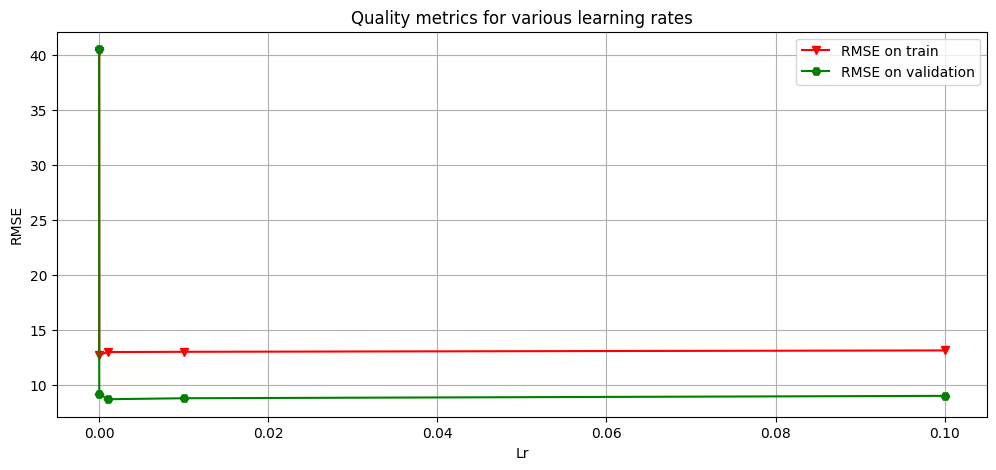

In [386]:
plt.figure(figsize=(12, 5))
plt.plot(lrs, rmse_lr_tr, label='RMSE on train', color='red', marker='v')
plt.plot(lrs, rmse_lr_val, label='RMSE on validation', color='green', marker='H')
plt.xlabel('Lr')
plt.ylabel('RMSE')
plt.title('Quality metrics for various learning rates')
plt.legend()
plt.grid(True)
plt.show()

In [383]:
print(rmse_lr_val)
print(rmse_lr_tr)

[40.4962043762207, 9.18502140045166, 8.696120262145996, 8.785057067871094, 9.00197696685791]
[40.34126663208008, 12.706069946289062, 12.981268882751465, 13.004898071289062, 13.130011558532715]


Исключим из рассмотрения сильно выбивающийся ноль, чтобы были более явно видны значения метрики.

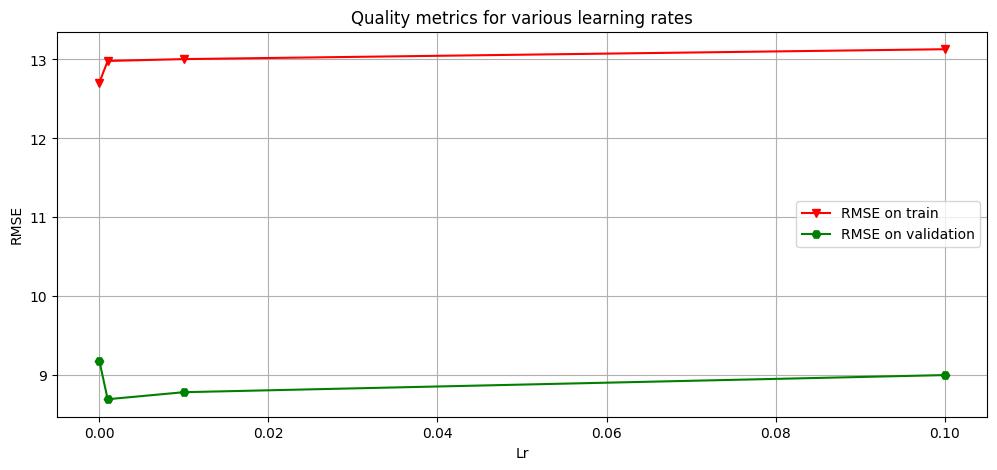

In [385]:
plt.figure(figsize=(12, 5))
plt.plot(lrs[1:], rmse_lr_tr[1:], label='RMSE on train', color='red', marker='v')
plt.plot(lrs[1:], rmse_lr_val[1:], label='RMSE on validation', color='green', marker='H')
plt.xlabel('Lr')
plt.ylabel('RMSE')
plt.title('Quality metrics for various learning rates')
plt.legend()
plt.grid(True)
plt.show()

Для валидационной выборки наименьшее значение RMSE достигается при lr = 1e-3, тогда как на тренировочной при lr = 1e-5. В данном случае, я буду опираться на валидационную как наиболее корректную, к тому же в тренировочной 1e-3 следующее после 1e-5 значение на выбор. Примечательно, что RMSE на тренировочной меньше, чем на валидационной, что говорит о качестве модели на отложенных данных.

In [387]:
g = set_global_seed(42)
rmse_wd_tr = []
rmse_wd_val = []
for w_d in weight_decays:
  model = NeuralNet().to(device)
  optimizer = torch.optim.Adam(model.parameters(), 1e-3, weight_decay=w_d)
  criterion = nn.MSELoss()
  epochs = 6
  train(model, optimizer, criterion, train_loader, val_loader, epochs)
  y_pred = predict(model, train_loader)
  y_pred = denormalize(y_pred)
  rmse_train = (torch.mean((y_pred - torch.tensor(y_train))**2))**0.5
  rmse_wd_tr.append(rmse_train.item())
  y_pred = predict(model, val_loader)
  y_pred = denormalize(y_pred)
  rmse_val = (torch.mean((y_pred - torch.tensor(y_val))**2))**0.5
  rmse_wd_val.append(rmse_val.item())
  print(f"Weight decay: {w_d}, RMSE train: {rmse_train}, RMSE val: {rmse_val}")

Training 1/6:   0%|          | 0/5369 [00:00<?, ?it/s]

Validating 1/6:   0%|          | 0/1790 [00:00<?, ?it/s]

Training 2/6:   0%|          | 0/5369 [00:00<?, ?it/s]

Validating 2/6:   0%|          | 0/1790 [00:00<?, ?it/s]

Training 3/6:   0%|          | 0/5369 [00:00<?, ?it/s]

...

Training 6/6:   0%|          | 0/5369 [00:00<?, ?it/s]

Validating 6/6:   0%|          | 0/1790 [00:00<?, ?it/s]

Predict:   0%|          | 0/5369 [00:00<?, ?it/s]

Predict:   0%|          | 0/1790 [00:00<?, ?it/s]

Weight decay: 0.1, RMSE train: 19.081676483154297, RMSE val: 19.113811492919922


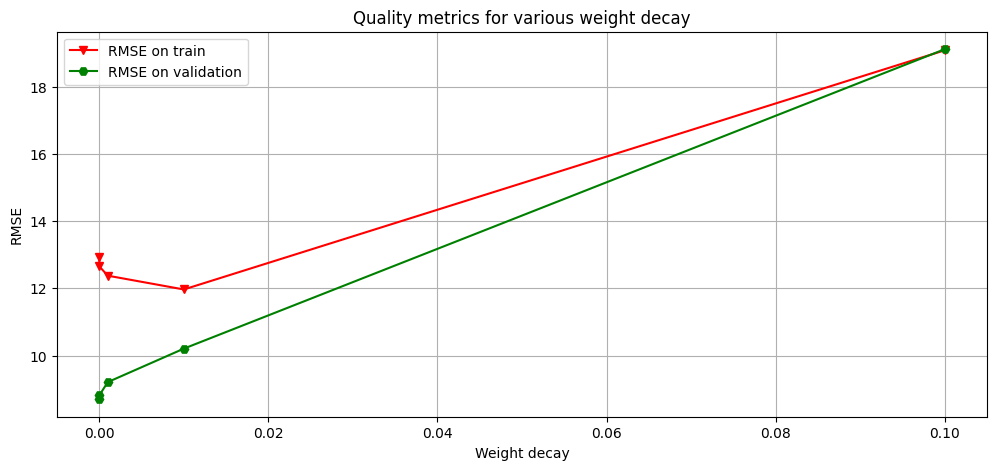

In [400]:
plt.figure(figsize=(12, 5))
plt.plot(weight_decays, rmse_wd_tr, label='RMSE on train', color='red', marker='v')
plt.plot(weight_decays, rmse_wd_val, label='RMSE on validation', color='green', marker='H')
plt.xlabel('Weight decay')
plt.ylabel('RMSE')
plt.title('Quality metrics for various weight decay')
plt.legend()
plt.grid(True)
plt.show()

Опишите результаты экспериментов (без их описания за работу ставится ноль баллов)

С учетом того, что на валидационной выборке лучше всего выглядит отсутствие weight decays, а для тренировочной разница довольно невелика, то имеет смысл отказаться от weight decay и оставить только learning rate = 1e-3.

> Как вы могли заметить, еще одна рутина DL-инженера &mdash; утомительное ожидание обучения моделей.




**Задание 13 (6 баллов).**

Думаю, направление размышлений вы поняли. Постарайтесь с помощью своих экспериментов выбить максимально возможное значение RMSE на тестовой выборке. Соотношение между полученным значением метрики на тестовой выборке и баллами за задание следующее:

- $\text{RMSE} \le 8.90 $ &mdash; 2 балла
- $\text{RMSE} \le 8.80 $ &mdash; 4 балла
- $\text{RMSE} \le 8.75 $ &mdash; 6 баллов

**Различные трюки, которые можно попробовать:**

1. Попробуйте делать во время обучения раннюю остановку обучения и сохранять модель в тот момент, когда качество на валидации начало ухудшаться, то есть модель начала переобучаться
2. Попробуйте усложнить архитектуру нейросет
    - Больше/меньше нейронов
    - Больше/меньше слоёв
    - Другие функции активации (tanh, relu, leaky relu, elu etc)
    - Регуляризация (dropout, l1,l2)
3. Попробуйте другие оптимизаторы, а также смену скорости обучения по расписанию.

И это далеко не полный список. Обратите внимание, что делать grid_search для больших сеток это довольно времязатратное занятие... Попробовать несколько значений, как мы делали в заданиях выше, адекватно, но делать какой-то огромный перебор будет самоубийством.

Логгируйте свои эксперименты. За один прогон пробуйте одно изменение. Иначе будет непонятно какие именно изменения улучшили качество, а какие ухудшили.

In [391]:
class NeuralNet(nn.Module):
    def __init__(self):

      super().__init__()
      self.model = nn.Sequential(
          nn.Linear(90, 128),
          nn.BatchNorm1d(128),
          nn.ReLU(),
          nn.Linear(128, 128),
          nn.BatchNorm1d(128),
          nn.ReLU(),
          nn.Linear(128, 1),
          nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [392]:
class SongDataset(torch.utils.data.Dataset):

    def __init__(self, x, y):
        self.x=x
        self.y=y

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return {'sample': torch.tensor(self.x[idx, :], dtype=torch.float), 'target': torch.tensor(self.y[idx], dtype=torch.float32)}

In [393]:
y_train_tr = normalize(y_train).astype(np.float32).reshape(-1, 1)
y_val_tr = normalize(y_val).astype(np.float32).reshape(-1, 1)
y_test_tr = normalize(y_test).astype(np.float32).reshape(-1, 1)

In [394]:
train_dataset = SongDataset(scaler.transform(X_train), y_train_tr)
val_dataset = SongDataset(scaler.transform(X_val), y_val_tr)
test_dataset = SongDataset(scaler.transform(X_test), y_test_tr)
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=64, shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=64, shuffle=False
)
val_loader = torch.utils.data.DataLoader(
    val_dataset, batch_size=64, shuffle=False
)

In [395]:
model = NeuralNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()
epochs = 6

In [396]:
g = set_global_seed(42)
data = train(model, optimizer, criterion, train_loader, val_loader, epochs)

Training 1/6:   0%|          | 0/4530 [00:00<?, ?it/s]

Validating 1/6:   0%|          | 0/1510 [00:00<?, ?it/s]

Training 2/6:   0%|          | 0/4530 [00:00<?, ?it/s]

Validating 2/6:   0%|          | 0/1510 [00:00<?, ?it/s]

Training 3/6:   0%|          | 0/4530 [00:00<?, ?it/s]

...

Validating 4/6:   0%|          | 0/1510 [00:00<?, ?it/s]

Training 5/6:   0%|          | 0/4530 [00:00<?, ?it/s]

Validating 5/6:   0%|          | 0/1510 [00:00<?, ?it/s]

Training 6/6:   0%|          | 0/4530 [00:00<?, ?it/s]

Validating 6/6:   0%|          | 0/1510 [00:00<?, ?it/s]

In [397]:
train_loss = data[0]
print('Train loss for final model')
for epoch, loss in enumerate(train_loss):
  print(f'Epoch: {epoch + 1}. Loss: {loss}')

Train loss for final model
Epoch: 1. Loss: 0.010991068979217707
Epoch: 2. Loss: 0.009896215126700763
Epoch: 3. Loss: 0.00966521856809981
Epoch: 4. Loss: 0.009494569073064568
Epoch: 5. Loss: 0.009360458062628745
Epoch: 6. Loss: 0.009244355064687012


In [398]:
val_loss = data[1]
print('Validation loss for final model')
for epoch, loss in enumerate(val_loss):
  print(f'Epoch: {epoch + 1}. Loss: {loss}')

Validation loss for final model
Epoch: 1. Loss: 0.010091349735036375
Epoch: 2. Loss: 0.009867446181148007
Epoch: 3. Loss: 0.009753098494803044
Epoch: 4. Loss: 0.009747977171829824
Epoch: 5. Loss: 0.009599135544174046
Epoch: 6. Loss: 0.009559606193580667


In [399]:
g = set_global_seed(42)
y_pred = predict(model, test_loader)
y_pred = denormalize(y_pred)
rmse = (torch.mean((y_pred - torch.tensor(y_test))**2))**0.5
print(f'The best RMSE: {rmse:.5f}')

Predict:   0%|          | 0/2014 [00:00<?, ?it/s]

The best RMSE: 8.68307


Опишите результаты экспериментов (без их описания за работу ставится ноль баллов)

Мной была выбрана стратегия подбора гиперпараметров модели на основе предыдущих пунктов (выбор из трех альтернатив - изменение на первую опцию, на вторую и оставление параметра неизменным). Выбиралось то, что позволяло сильнее всего понизить лосс и RMSE. Так было выбрано: оптимизация ADAM вместо SGD+momentum, добавление линейного слоя с функцией активации ReLU, batch нормализация в качестве регуляризации,learning rate равный 1e-3, а от weight decay было решено отказаться.
Эта модель была протестирована и вышел RMSE 8.68, что значительно ниже 8.75. С учетом и так очень высокого качества модели, эти параметры, выбранные в прошлых пунктах экспериментальным путем, будут оставлены как итоговые.

## Бонус (0.1 балла)

Прикрепите фотографию того, как вы начали этот сентябрь. Какую самую классную эмоцию вы испытали за прошедший месяц?

*Восхищение от новых необычных мест, посещенных мной в Азии. Вот древний дворец Сеула на фоне гор.*

<img src="https://raw.githubusercontent.com/berdjs0/images/main/Сеул.jpg" width="250" height="400" alt="Моё крутое фото">